In [579]:
!pip install pandas matplotlib seaborn numpy scipy -q

## Импорты

In [580]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('display.max_columns', 50)

## Смотрим на даатсет

In [581]:
df = pd.read_csv('games_with_sales.csv', parse_dates=['first_release_date'])
df.head()

,first_release_date,game_modes,genres,name,platforms,rating,summary,themes,total_rating,game_type,storyline,age_ratings,hypes,total_sales,na_sales,jp_sales,pal_sales,other_sales,sales_platform
0,2022-04-12,"Single player, Multiplayer, Co-operative","Shooter, Racing, Adventure",Grand Theft Auto V,"['Xbox Series X|S', 'PlayStation 5']",99.596210,A new generation of Grand Theft Auto V featuri...,"Action, Comedy, Open world",99.596210,3,NaN,"[211581, 211580, 126201, 108449, 126200, 83487...",3.0,220.00,NaN,NaN,NaN,NaN,NaN
1,1999-11-02,Single player,Role-playing (RPG),Chrono Trigger,"['PlayStation 3', 'PlayStation', 'PlayStation ...",98.599448,An enhanced port of Chrono Trigger that adds a...,"Action, Fantasy, Science fiction",98.599448,10,This is the fateful story of those who discove...,"[163482, 163481]",NaN,5.00,NaN,NaN,NaN,NaN,NaN
2,2001-06-22,Single player,"Puzzle, Adventure",Alone in the Dark: The New Nightmare,"['PC (Microsoft Windows)', 'Dreamcast', 'PlayS...",98.368902,"The Dreamcast, PC and PlayStation 2 ports of A...","Action, Horror, Survival, Mystery",98.368902,11,"Set on October 31, 2001, Edward Carnby’s best ...","[172145, 172148, 172147, 172146]",NaN,1.40,NaN,NaN,NaN,NaN,NaN
3,1993-12-31,"Single player, Split screen","Shooter, Adventure",Jurassic Park,['Nintendo Entertainment System'],97.226432,Jurassic Park is a top-down action-adventure g...,Action,97.226432,0,JURASSIC PARK starts just after the T-Rex push...,NaN,NaN,7.57,NaN,NaN,NaN,NaN,NaN
4,2022-02-25,"Single player, Multiplayer, Co-operative","Role-playing (RPG), Adventure",Elden Ring,"['Xbox Series X|S', 'PlayStation 4', 'Nintendo...",93.576279,Elden Ring is an action RPG developed by FromS...,"Action, Fantasy, Open world",95.238140,0,"Elden Ring takes place in the Lands Between, a...","[57167, 57169, 213790, 57164, 57168, 57165, 57...",96.0,30.00,NaN,NaN,NaN,NaN,NaN


In [582]:
df.loc[df['name'] == 'Unreal Tournament', 'first_release_date'] = pd.to_datetime('30 November 1999')

In [583]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15602 entries, 0 to 15601
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   first_release_date  15599 non-null  datetime64[us]
 1   game_modes          15465 non-null  str           
 2   genres              15561 non-null  str           
 3   name                15602 non-null  str           
 4   platforms           15602 non-null  str           
 5   rating              15481 non-null  float64       
 6   summary             15587 non-null  str           
 7   themes              14744 non-null  str           
 8   total_rating        15602 non-null  float64       
 9   game_type           15602 non-null  int64         
 10  storyline           6488 non-null   str           
 11  age_ratings         14759 non-null  str           
 12  hypes               5233 non-null   float64       
 13  total_sales         7816 non-null   float64       
 14  n

## Добавим новые признаки

In [584]:
df['year'] = df['first_release_date'].dt.year
df['month'] = df['first_release_date'].dt.month

In [585]:
# Заменим платформы на All в играх где данные по всем платформам
df.loc[df['sales_platform'].isna(), 'platforms'] = 'All'

## Посмотрим пересечнеие между ALL и не ALL

In [586]:
df_all = set(df[df['sales_platform'].isna()]['name'].unique())
df_plat = set(df[~df['sales_platform'].isna()]['name'].unique())

perec = df_all & df_plat
print(len(perec))

920


Как мы видим почти все игры с данными по всем платформам присутствуют в разбиении по платформам

In [587]:
df = df.sort_values('total_sales', ascending=False).drop_duplicates(subset=['name', 'platforms'], keep='first')

In [588]:
df = df.drop_duplicates(subset = ['name', 'platforms'])

In [589]:
df[df['name'].str.lower().str.contains('grand theft auto v', na=False)]

,first_release_date,game_modes,genres,name,platforms,rating,summary,themes,total_rating,game_type,storyline,age_ratings,hypes,total_sales,na_sales,jp_sales,pal_sales,other_sales,sales_platform,year,month
151,2015-04-14,"Single player, Multiplayer, Co-operative","Shooter, Racing, Arcade",Grand Theft Auto V,All,87.342582,This bundle contains the original version of G...,"Action, Sandbox, Open world",87.342582,3,NaN,"[207400, 151443, 145893, 178899, 178947]",NaN,220.00,NaN,NaN,NaN,NaN,NaN,2015.0,4.0
2072,2013-09-17,"Single player, Multiplayer, Co-operative","Shooter, Racing, Adventure",Grand Theft Auto V,PlayStation 3,89.611105,Grand Theft Auto V is a vast open world game s...,"Action, Comedy, Sandbox, Open world",88.874518,0,Los Santos: a sprawling sun-soaked metropolis ...,"[47895, 47891, 111359, 213788, 47892, 47894, 4...",NaN,20.32,6.37,0.99,9.85,3.12,PS3,2013.0,9.0
2560,2015-04-14,"Single player, Multiplayer, Co-operative","Shooter, Racing, Arcade",Grand Theft Auto V,PlayStation 4,87.342582,This bundle contains the original version of G...,"Action, Sandbox, Open world",87.342582,3,NaN,"[207400, 151443, 145893, 178899, 178947]",NaN,19.39,6.06,0.60,9.71,3.02,PS4,2015.0,4.0
2083,2013-09-17,"Single player, Multiplayer, Co-operative","Shooter, Racing, Adventure",Grand Theft Auto V,Xbox 360,89.611105,Grand Theft Auto V is a vast open world game s...,"Action, Comedy, Sandbox, Open world",88.874518,0,Los Santos: a sprawling sun-soaked metropolis ...,"[47895, 47891, 111359, 213788, 47892, 47894, 4...",NaN,15.86,9.06,0.06,5.33,1.42,X360,2013.0,9.0
2563,2015-04-14,"Single player, Multiplayer, Co-operative","Shooter, Racing, Arcade",Grand Theft Auto V,PC (Microsoft Windows),87.342582,This bundle contains the original version of G...,"Action, Sandbox, Open world",87.342582,3,NaN,"[207400, 151443, 145893, 178899, 178947]",NaN,12.60,NaN,NaN,NaN,NaN,PC,2015.0,4.0
2567,2015-04-14,"Single player, Multiplayer, Co-operative","Shooter, Racing, Arcade",Grand Theft Auto V,Xbox One,87.342582,This bundle contains the original version of G...,"Action, Sandbox, Open world",87.342582,3,NaN,"[207400, 151443, 145893, 178899, 178947]",NaN,8.72,4.70,0.01,3.25,0.76,XOne,2015.0,4.0
1263,2022-04-12,"Single player, Multiplayer, Co-operative","Shooter, Racing, Adventure",Grand Theft Auto V,Xbox Series X|S,99.596210,A new generation of Grand Theft Auto V featuri...,"Action, Comedy, Open world",99.596210,3,NaN,"[211581, 211580, 126201, 108449, 126200, 83487...",3.0,NaN,NaN,NaN,NaN,NaN,XS,2022.0,4.0
1266,2022-04-12,"Single player, Multiplayer, Co-operative","Shooter, Racing, Adventure",Grand Theft Auto V,PlayStation 5,99.596210,A new generation of Grand Theft Auto V featuri...,"Action, Comedy, Open world",99.596210,3,NaN,"[211581, 211580, 126201, 108449, 126200, 83487...",3.0,NaN,NaN,NaN,NaN,NaN,PS5,2022.0,4.0


In [590]:
df.info()

<class 'pandas.DataFrame'>
Index: 13978 entries, 191 to 15598
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   first_release_date  13976 non-null  datetime64[us]
 1   game_modes          13853 non-null  str           
 2   genres              13952 non-null  str           
 3   name                13978 non-null  str           
 4   platforms           13978 non-null  str           
 5   rating              13859 non-null  float64       
 6   summary             13966 non-null  str           
 7   themes              13208 non-null  str           
 8   total_rating        13978 non-null  float64       
 9   game_type           13978 non-null  int64         
 10  storyline           5720 non-null   str           
 11  age_ratings         13281 non-null  str           
 12  hypes               4917 non-null   float64       
 13  total_sales         6811 non-null   float64       
 14  na_s

## Найдем что нибудь интересное

In [591]:
df_all = df.query('total_sales > 0')
df_all.info()

<class 'pandas.DataFrame'>
Index: 6575 entries, 191 to 15435
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   first_release_date  6575 non-null   datetime64[us]
 1   game_modes          6507 non-null   str           
 2   genres              6556 non-null   str           
 3   name                6575 non-null   str           
 4   platforms           6575 non-null   str           
 5   rating              6544 non-null   float64       
 6   summary             6566 non-null   str           
 7   themes              6139 non-null   str           
 8   total_rating        6575 non-null   float64       
 9   game_type           6575 non-null   int64         
 10  storyline           2541 non-null   str           
 11  age_ratings         6368 non-null   str           
 12  hypes               1531 non-null   float64       
 13  total_sales         6575 non-null   float64       
 14  na_sa

In [592]:
# Посмотрим что за пропуски в дате релиза
df_all[df_all['first_release_date'].isna()]

,first_release_date,game_modes,genres,name,platforms,rating,summary,themes,total_rating,game_type,storyline,age_ratings,hypes,total_sales,na_sales,jp_sales,pal_sales,other_sales,sales_platform,year,month


In [593]:
df_all.loc[df_all['name'] == 'Unreal Tournament', 'first_release_date'] = pd.to_datetime('30 November 1999')


In [594]:
df_all.info()

<class 'pandas.DataFrame'>
Index: 6575 entries, 191 to 15435
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   first_release_date  6575 non-null   datetime64[us]
 1   game_modes          6507 non-null   str           
 2   genres              6556 non-null   str           
 3   name                6575 non-null   str           
 4   platforms           6575 non-null   str           
 5   rating              6544 non-null   float64       
 6   summary             6566 non-null   str           
 7   themes              6139 non-null   str           
 8   total_rating        6575 non-null   float64       
 9   game_type           6575 non-null   int64         
 10  storyline           2541 non-null   str           
 11  age_ratings         6368 non-null   str           
 12  hypes               1531 non-null   float64       
 13  total_sales         6575 non-null   float64       
 14  na_sa

Как мы видим у нас тут есть данные максимум у 6680к игро-платформ

In [595]:
df_unique_games = df_all.sort_values('year', ascending=True).drop_duplicates(subset='name', keep='first')

counts = df_unique_games['year'].value_counts().reset_index().astype(int)
counts.head()

,year,count
0,2015,184
1,2011,182
2,2016,180
3,2009,178
4,2005,172


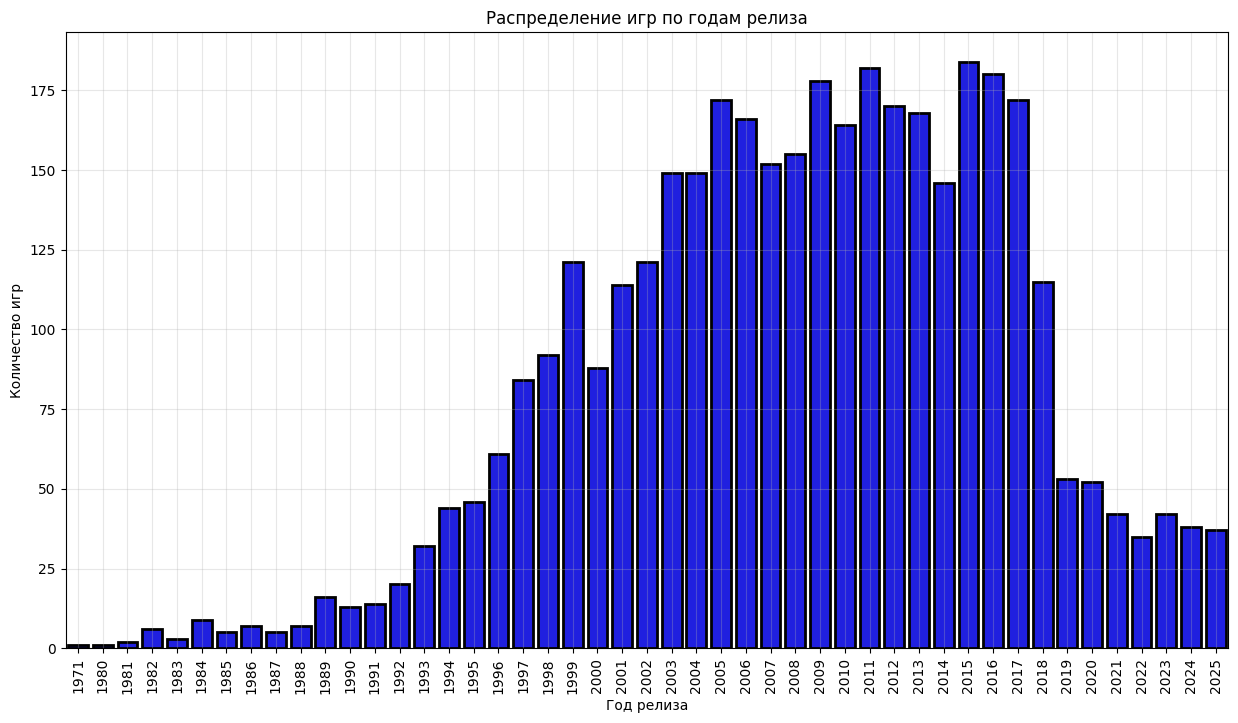

In [596]:
plt.figure(figsize=(15, 8))

sns.barplot(counts, x='year', y='count', color='blue', edgecolor='black', linewidth=2)

plt.grid(True, alpha = 0.3)
plt.title('Распределение игр по годам релиза')
plt.xlabel('Год релиза')
plt.ylabel('Количество игр')
plt.xticks(rotation=90)

plt.show()

Как мы видим захватываем понемного все времена

## Смотрим на продажи по годам 

In [597]:
longest_string = lambda x: max(x.dropna(), key=len) if not x.dropna().empty else None

In [598]:
df_all['is_all'] = df_all['platforms'] == 'All'

has_all = df_all.groupby(['name', 'year'])['is_all'].transform('any')

# где All есть оставляем только строки All
df_with_all = df_all[has_all & df_all['is_all']][['name', 'year', 'total_sales', 'first_release_date', 'genres', 'themes', 'game_modes']]

game_has_all = df_all.groupby('name')['is_all'].transform('any')
# где All нет сумма по всем платформам
df_without_all = df_all[~game_has_all].copy()

df_without_all = df_without_all.groupby(['name', 'year']).agg({'total_sales': 'sum','first_release_date': 'min', 'genres': 'first', 'themes' : longest_string, 'game_modes': longest_string}).reset_index()


display(df_with_all.head())
display(df_without_all.head())

,name,year,total_sales,first_release_date,genres,themes,game_modes
191,Tetris,1989.0,520.0,1989-11-01,"Puzzle, Arcade",NaN,Single player
308,Call of Duty,2003.0,500.0,2003-10-29,Shooter,"Action, Historical, Warfare","Single player, Multiplayer"
798,Grand Theft Auto,1997.0,460.0,1997-10-21,"Shooter, Racing, Adventure","Action, Sandbox, Open world","Single player, Multiplayer"
500,Minecraft,2016.0,350.0,2016-12-19,"Simulator, Adventure, Arcade","Action, Fantasy, Survival, Sandbox, Kids, Open...","Single player, Multiplayer, Co-operative, Spli..."
851,Assassin's Creed,2007.0,230.0,2007-11-13,"Platform, Adventure","Action, Fantasy, Science fiction, Historical, ...",Single player


,name,year,total_sales,first_release_date,genres,themes,game_modes
0,.Hack//G.U. Vol. 1: Rebirth,2006.0,0.16,2006-05-18,Role-playing (RPG),"Action, Fantasy, Science fiction",Single player
1,140,2013.0,0.14,2013-10-16,"Music, Platform, Puzzle, Strategy, Indie",Action,Single player
2,2010 FIFA World Cup South Africa,2010.0,2.08,2010-04-27,"Simulator, Sport","Action, Non-fiction","Single player, Split screen"
3,2014 FIFA World Cup Brazil,2014.0,1.10,2014-04-15,Sport,Non-fiction,"Single player, Multiplayer, Split screen"
4,20XX,2017.0,0.11,2017-08-16,"Shooter, Platform, Adventure, Indie, Arcade","Action, Science fiction","Single player, Multiplayer, Co-operative"


In [599]:
sales_games_all = pd.concat([df_with_all, df_without_all], ignore_index=True)
sales_games_all['year'] = sales_games_all['year'].astype('int')
sales = sales_games_all.groupby('year')['total_sales'].sum().reset_index()

In [600]:
df_with_all[df_with_all['name'].str.lower().str.contains('grand theft auto v')]

,name,year,total_sales,first_release_date,genres,themes,game_modes
151,Grand Theft Auto V,2015.0,220.0,2015-04-14,"Shooter, Racing, Arcade","Action, Sandbox, Open world","Single player, Multiplayer, Co-operative"


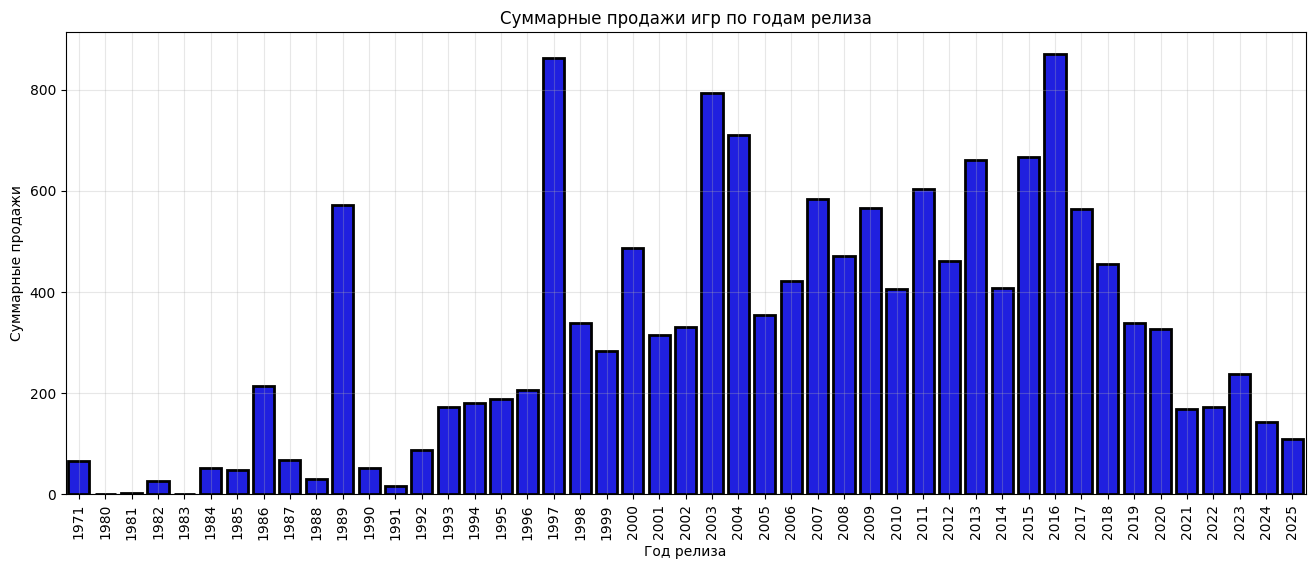

In [601]:
plt.figure(figsize=(16, 6))
sns.barplot(sales, x='year', y='total_sales', color='blue', edgecolor='black',linewidth=2)

plt.grid(True, alpha = 0.3)
plt.title('Суммарные продажи игр по годам релиза')
plt.xlabel('Год релиза')
plt.ylabel('Суммарные продажи')
plt.xticks(rotation=90)

plt.show()

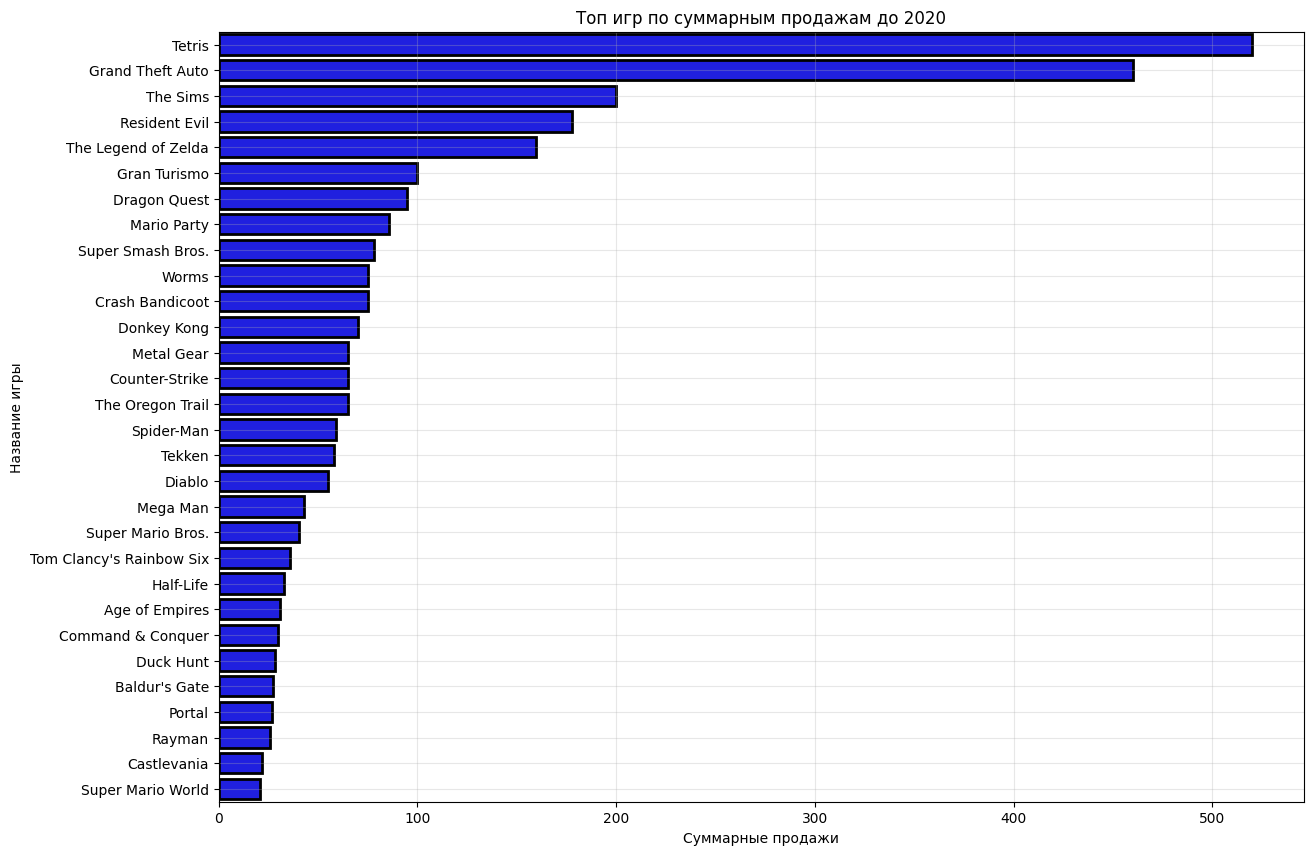

In [602]:
top_sales = sales_games_all[(sales_games_all['year'] <= 2000)].sort_values(by= 'total_sales', ascending = False)[['total_sales', 'name']].head(30)

plt.figure(figsize=(14, 10))

sns.barplot(top_sales, x ='total_sales', y='name', color='blue', edgecolor='black', linewidth=2)

plt.grid(True, alpha=0.3)
plt.title('Топ игр по суммарным продажам до 2020')
plt.xlabel('Суммарные продажи')
plt.ylabel('Название игры')

plt.show()

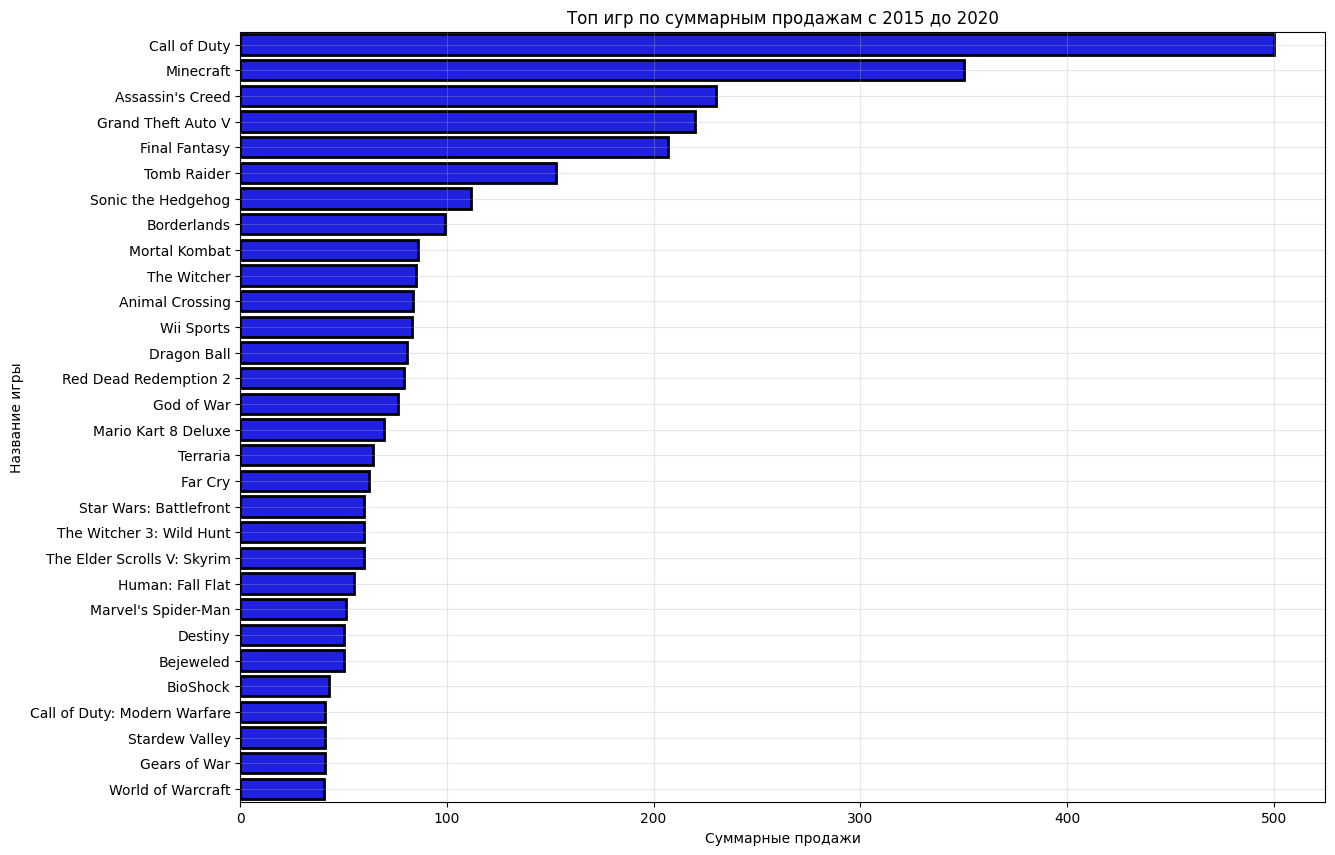

In [603]:
top_sales = sales_games_all[(sales_games_all['year'] < 2020) & (sales_games_all['year'] > 2000)].sort_values(by= 'total_sales', ascending = False)[['total_sales', 'name']].head(30)

plt.figure(figsize=(14, 10))

sns.barplot(top_sales, x ='total_sales', y='name', color='blue', edgecolor='black', linewidth=2)

plt.grid(True, alpha=0.3)
plt.title('Топ игр по суммарным продажам c 2015 до 2020')
plt.xlabel('Суммарные продажи')
plt.ylabel('Название игры')

plt.show()

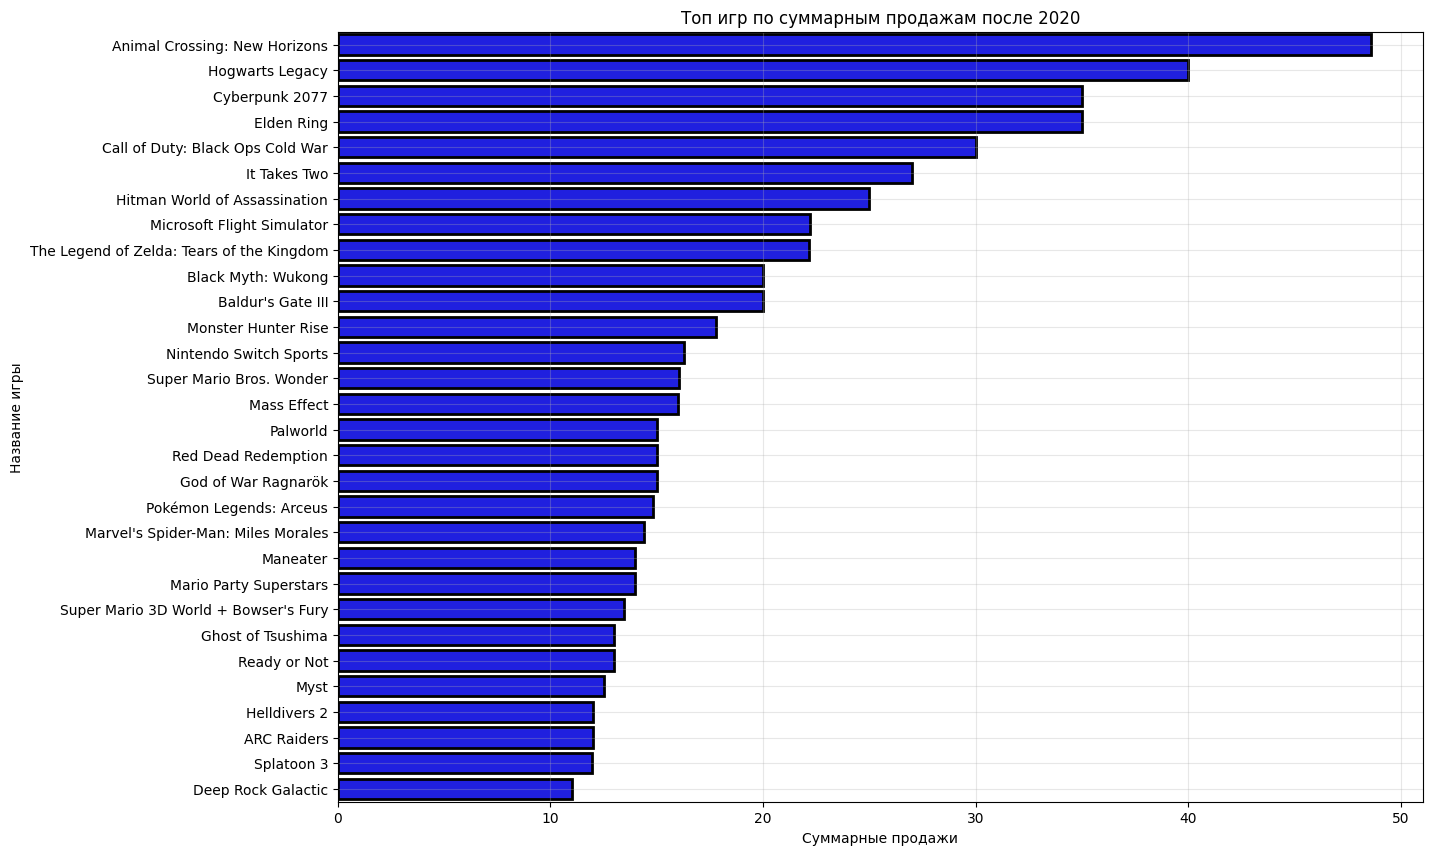

In [604]:
top_sales = sales_games_all[sales_games_all['year'] >= 2020].sort_values(by= 'total_sales', ascending = False)[['total_sales', 'name']].head(30)

plt.figure(figsize=(14, 10))

sns.barplot( top_sales, x='total_sales', y='name', color='blue', edgecolor='black', linewidth=2)

plt.grid(True, alpha=0.3)
plt.title('Топ игр по суммарным продажам после 2020')
plt.xlabel('Суммарные продажи')
plt.ylabel('Название игры')

plt.show()

## Смотрим на продажи по жанрам

In [605]:
df_genres = sales_games_all.copy()

df_genres['genres'] = df_genres['genres'].str.split(', ')
df_genres = df_genres.explode('genres')

df_genres.head()

,name,year,total_sales,first_release_date,genres,themes,game_modes
0,Tetris,1989,520.0,1989-11-01,Puzzle,NaN,Single player
0,Tetris,1989,520.0,1989-11-01,Arcade,NaN,Single player
1,Call of Duty,2003,500.0,2003-10-29,Shooter,"Action, Historical, Warfare","Single player, Multiplayer"
2,Grand Theft Auto,1997,460.0,1997-10-21,Shooter,"Action, Sandbox, Open world","Single player, Multiplayer"
2,Grand Theft Auto,1997,460.0,1997-10-21,Racing,"Action, Sandbox, Open world","Single player, Multiplayer"


In [606]:
genre_counts = df_genres['genres'].value_counts().reset_index()
genre_sales = df_genres.groupby('genres')['total_sales'].sum().reset_index()
genre_order = genre_sales.sort_values(by='total_sales', ascending=False)['genres']

genre_counts['genres'] = pd.Categorical(genre_counts['genres'], categories=genre_order, ordered=True)
genre_sales['genres'] = pd.Categorical(genre_sales['genres'], categories=genre_order, ordered=True)

genre_counts = genre_counts.sort_values('genres')
genre_sales = genre_sales.sort_values('genres')

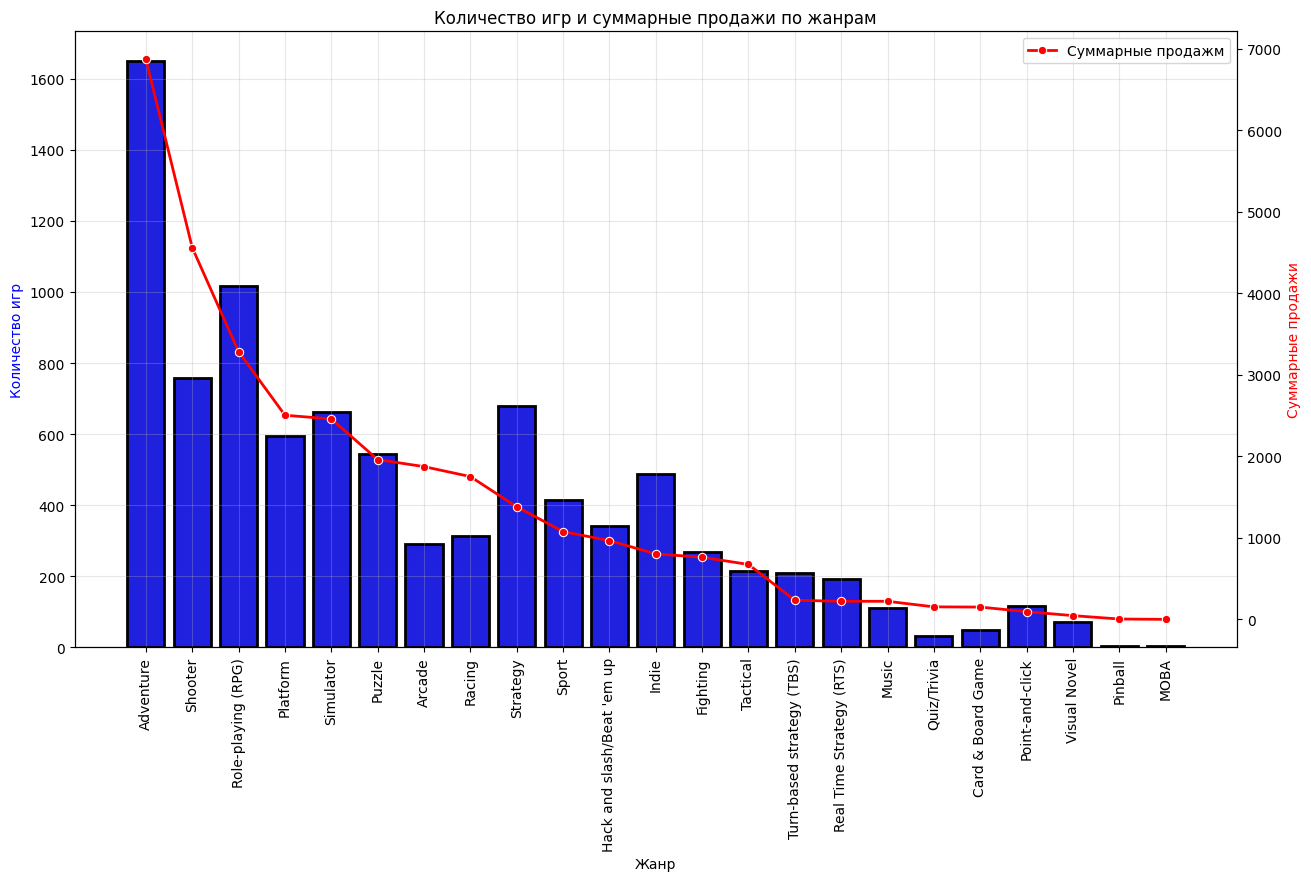

In [607]:
fig, ax1 = plt.subplots(figsize=(15, 8))

sns.barplot(data=genre_counts, x='genres', y='count', color='blue', edgecolor='black', linewidth=2, ax=ax1)

plt.grid(True, alpha = 0.3)
ax1.set_title('Количество игр и суммарные продажи по жанрам')
ax1.set_xlabel('Жанр')
ax1.set_ylabel('Количество игр', color = 'blue')
ax1.tick_params(axis='x', rotation=90)


ax2 = ax1.twinx()
sns.lineplot(data=genre_sales, x='genres', y='total_sales', color='red', linewidth=2, marker='o', ax=ax2, label = 'Суммарные продажм')
ax2.set_ylabel('Суммарные продажи', color = 'red')

plt.show()

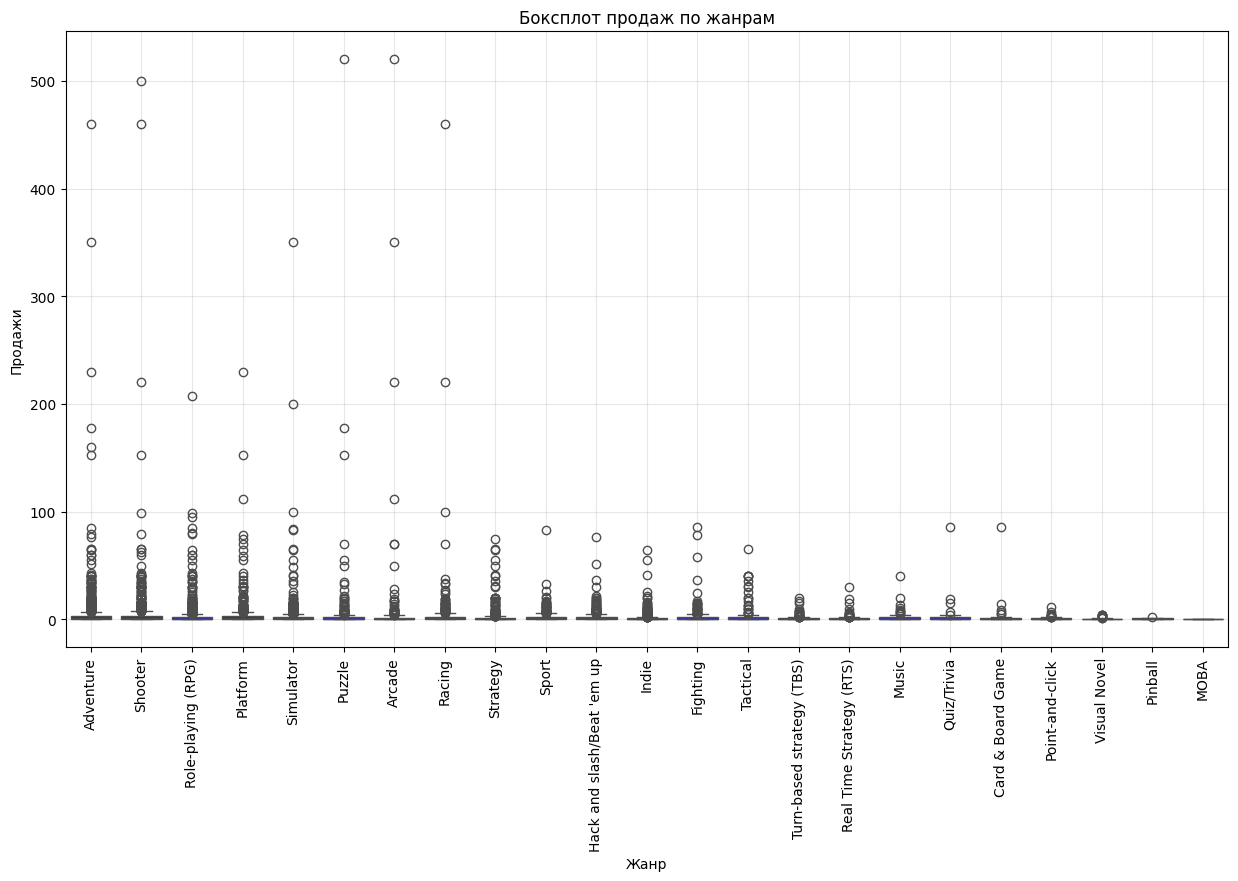

In [608]:
df_genres = df_genres.reset_index()
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_genres, x='genres', y='total_sales', color = 'Blue', order = genre_order)

plt.grid(True, alpha = 0.3)
plt.xticks(rotation=90)
plt.title('Боксплот продаж по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Продажи')
plt.show()

Как мы видим много выбросов, ограничим ось чтобы поближе посмотреть

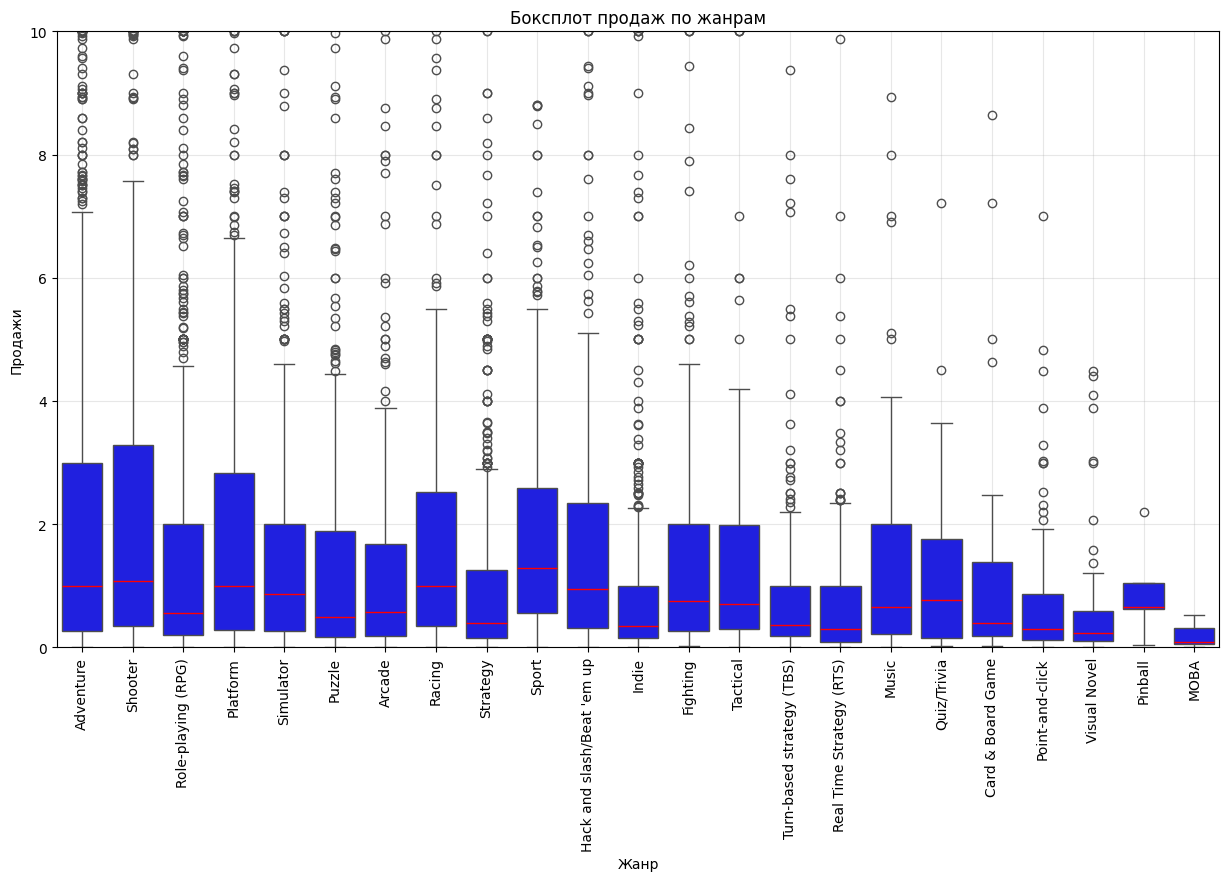

In [609]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_genres, x='genres', y='total_sales', order = genre_order, color = 'Blue',  medianprops={'color': 'red'})
plt.xticks(rotation=90)
plt.title('Боксплот продаж по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Продажи')
plt.ylim(0, 10)
plt.grid(True, alpha=0.3)
plt.show()

In [610]:
df_genres.head()
genre_year_counts = df_genres.groupby(['year', 'genres']).size().reset_index(name='count')
genre_year_counts.head()

,year,genres,count
0,1971,Adventure,1
1,1971,Simulator,1
2,1971,Strategy,1
3,1980,Adventure,1
4,1981,Arcade,2


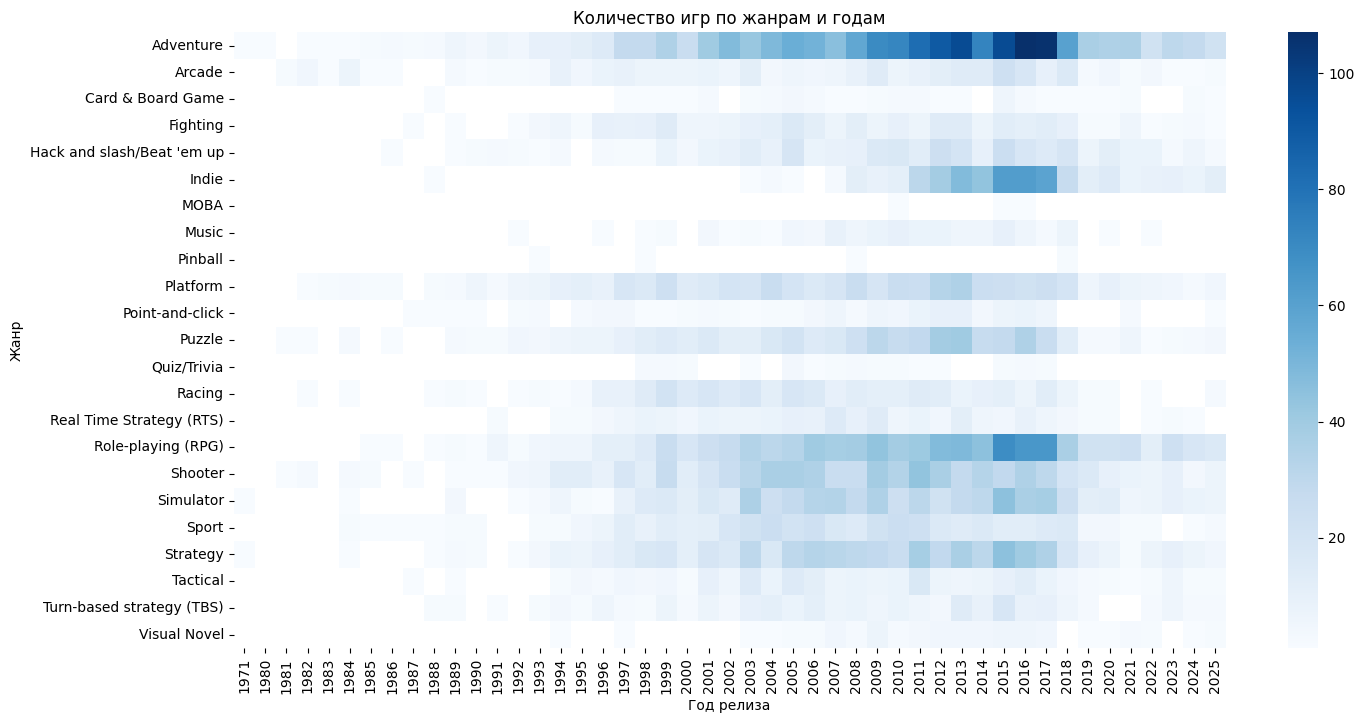

In [611]:
pivot_genre_year = genre_year_counts.pivot(index='genres', columns='year', values='count')
plt.figure(figsize=(16, 8))
sns.heatmap(pivot_genre_year, cmap='Blues',)
plt.title('Количество игр по жанрам и годам')
plt.xlabel('Год релиза')
plt.ylabel('Жанр')
plt.show()

## Посмотрим продаже по game_mods

In [612]:
df_modes = sales_games_all.copy()

df_modes['game_modes'] = df_modes['game_modes'].str.split(', ')
df_modes = df_modes.explode('game_modes').reset_index(drop = True)

df_modes.head()

,name,year,total_sales,first_release_date,genres,themes,game_modes
0,Tetris,1989,520.0,1989-11-01,"Puzzle, Arcade",NaN,Single player
1,Call of Duty,2003,500.0,2003-10-29,Shooter,"Action, Historical, Warfare",Single player
2,Call of Duty,2003,500.0,2003-10-29,Shooter,"Action, Historical, Warfare",Multiplayer
3,Grand Theft Auto,1997,460.0,1997-10-21,"Shooter, Racing, Adventure","Action, Sandbox, Open world",Single player
4,Grand Theft Auto,1997,460.0,1997-10-21,"Shooter, Racing, Adventure","Action, Sandbox, Open world",Multiplayer


In [613]:
df_modes[df_modes['game_modes'].str.contains('Battle')]

,name,year,total_sales,first_release_date,genres,themes,game_modes
3234,Fortnite,2020,2.37,2020-06-29,"Shooter, Role-playing (RPG), Simulator, Strate...","Action, Survival, Sandbox, Open world",Battle Royale
3244,Forza Horizon 4,2018,1.84,2018-10-02,"Racing, Sport, Adventure","Action, Open world",Battle Royale


In [614]:
mode_counts = df_modes['game_modes'].value_counts().reset_index()
mode_sales = df_modes.groupby('game_modes')['total_sales'].sum().reset_index()
mode_order = mode_sales.sort_values(by='total_sales', ascending=False)['game_modes']

mode_counts['game_modes'] = pd.Categorical(mode_counts['game_modes'], categories=mode_order, ordered=True)
mode_sales['game_modes'] = pd.Categorical(mode_sales['game_modes'], categories=mode_order, ordered=True)

mode_counts = mode_counts.sort_values('game_modes')
mode_sales = mode_sales.sort_values('game_modes')

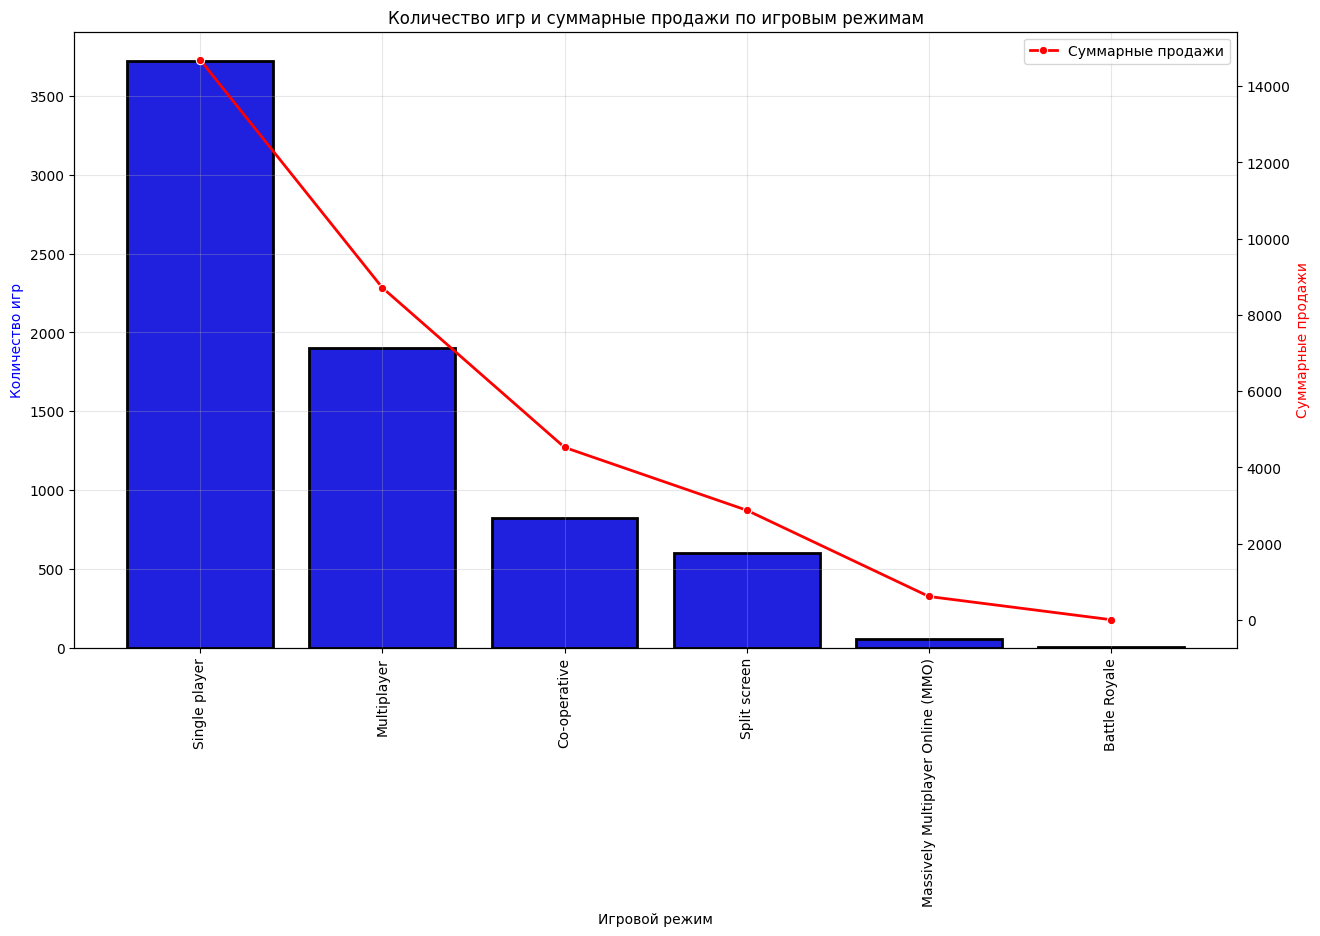

In [615]:
fig, ax1 = plt.subplots(figsize=(15, 8))

sns.barplot(data=mode_counts, x='game_modes', y='count', color='blue', edgecolor='black', linewidth=2, ax=ax1)

plt.grid(True, alpha=0.3)
ax1.set_title('Количество игр и суммарные продажи по игровым режимам')
ax1.set_xlabel('Игровой режим')
ax1.set_ylabel('Количество игр', color='blue')
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
sns.lineplot(data=mode_sales, x='game_modes', y='total_sales', color='red', linewidth=2, marker='o', ax=ax2, label='Суммарные продажи')
ax2.set_ylabel('Суммарные продажи', color='red')

plt.show()

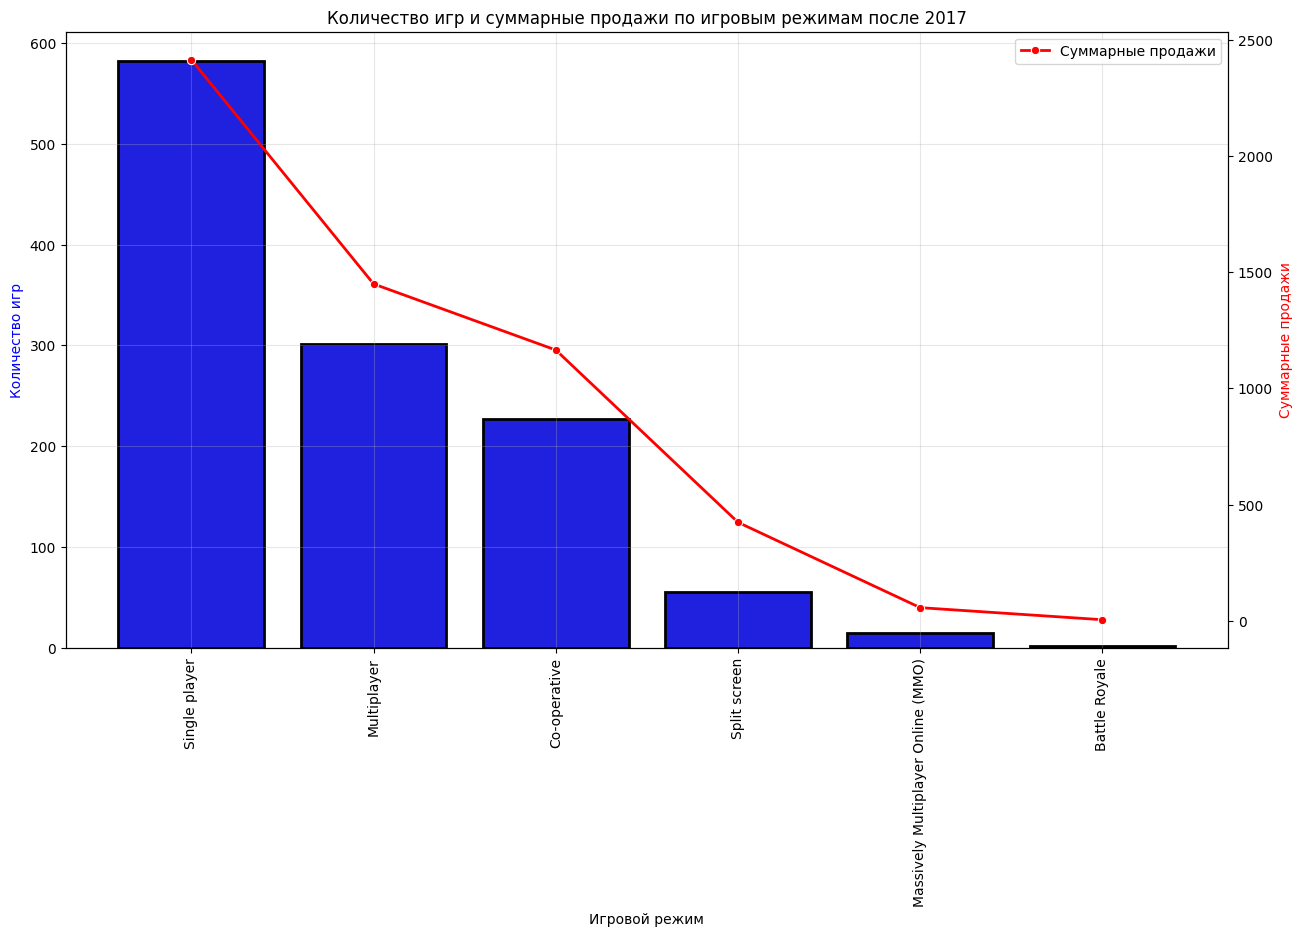

In [616]:
# Посмотрим то же самое но позже 2015 
df_modes_2015 = df_modes[df_modes['year'] >= 2017]

mode_counts_2015 = df_modes_2015['game_modes'].value_counts().reset_index()
mode_counts_2015.columns = ['game_modes', 'count']

mode_sales_2015 = df_modes_2015.groupby('game_modes', as_index=False)['total_sales'].sum()
mode_order_2015 = mode_sales_2015.sort_values(by='total_sales', ascending=False)['game_modes']

mode_counts_2015['game_modes'] = pd.Categorical(mode_counts_2015['game_modes'], categories=mode_order_2015, ordered=True)
mode_sales_2015['game_modes'] = pd.Categorical(mode_sales_2015['game_modes'], categories=mode_order_2015, ordered=True)

mode_counts_2015 = mode_counts_2015.sort_values('game_modes')
mode_sales_2015 = mode_sales_2015.sort_values('game_modes')

fig, ax1 = plt.subplots(figsize=(15, 8))

sns.barplot(data=mode_counts_2015, x='game_modes', y='count', color='blue', edgecolor='black', linewidth=2, ax=ax1)

plt.grid(True, alpha=0.3)
ax1.set_title('Количество игр и суммарные продажи по игровым режимам после 2017')
ax1.set_xlabel('Игровой режим')
ax1.set_ylabel('Количество игр', color='blue')
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
sns.lineplot(data=mode_sales_2015, x='game_modes', y='total_sales', color='red', linewidth=2, marker='o', ax=ax2, label='Суммарные продажи')
ax2.set_ylabel('Суммарные продажи', color='red')

plt.show()


## Посмотрим на продажи по платформам

In [617]:
# Смотрим именно на все что не All
plat_df = df_all[df_all['is_all'] == False]
plat_df.head()

,first_release_date,game_modes,genres,name,platforms,rating,summary,themes,total_rating,game_type,storyline,age_ratings,hypes,total_sales,na_sales,jp_sales,pal_sales,other_sales,sales_platform,year,month,is_all
11739,2006-11-19,"Single player, Multiplayer, Co-operative, Spli...","Simulator, Sport",Wii Sports,Wii,75.216607,Bowl like a pro or go for that home run...\nEx...,Party,75.108303,0,NaN,"[62413, 48968, 62415, 62416, 62414, 189, 36304]",NaN,82.90,NaN,NaN,NaN,NaN,Wii,2006.0,11.0,False
2187,2017-04-28,"Single player, Multiplayer, Split screen","Racing, Arcade",Mario Kart 8 Deluxe,Nintendo Switch,84.280094,Hit the road with the definitive version of Ma...,"Action, Fantasy, Kids, Party",88.551812,10,NaN,"[12329, 86513, 68115, 85481, 85482, 191101, 74...",7.0,69.56,NaN,NaN,NaN,NaN,NS,2017.0,4.0,False
2945,2020-03-20,"Single player, Multiplayer, Co-operative, Spli...",Simulator,Animal Crossing: New Horizons,Nintendo Switch,82.536021,Escape to a deserted island and create your ow...,"Sandbox, Kids, Open world",86.358919,0,If the hustle and bustle of modern life’s got ...,"[223704, 68111, 96819, 224499, 225618, 225619,...",29.0,48.62,NaN,NaN,NaN,NaN,NS,2020.0,3.0,False
4304,1985-09-13,"Single player, Multiplayer","Platform, Adventure",Super Mario Bros.,Nintendo Entertainment System,83.816154,A side scrolling 2D platformer and first entry...,Action,83.816154,0,One day the kingdom of the peaceful mushroom p...,"[50768, 24, 47142, 50767, 33840, 50769, 47471]",NaN,40.24,NaN,NaN,NaN,NaN,NES,1985.0,9.0,False
5992,2012-08-21,Multiplayer,"Shooter, Tactical",Counter-Strike: Global Offensive,PC (Microsoft Windows),81.724836,Counter-Strike: Global Offensive expands upon ...,"Action, Warfare",81.362418,0,NaN,"[81042, 81040, 81041, 81043, 189362]",NaN,40.00,NaN,NaN,NaN,NaN,PC,2012.0,8.0,False


In [618]:
platform_sales = plat_df.groupby('sales_platform')['total_sales'].sum().reset_index().sort_values('total_sales', ascending=False)

platform_sales

,sales_platform,total_sales
17,PC,1174.56
20,PS3,704.23
30,X360,691.74
21,PS4,661.60
19,PS2,611.35
15,NS,586.94
28,Wii,408.87
18,PS,326.41
4,DS,266.38
32,XOne,237.60


Возьмем более менее актуальные платформы

In [619]:
plats_list = ['XS', 'XOne', 'PS4', 'PS5', 'NS', 'NS2']
pc_sales = plat_df[plat_df['sales_platform'] == 'PC'].groupby('year')['total_sales'].sum().reset_index()
pc_sales.head()

,year,total_sales
0,1989.0,1.45
1,1991.0,0.13
2,1992.0,1.00
3,1993.0,4.51
4,1994.0,0.82


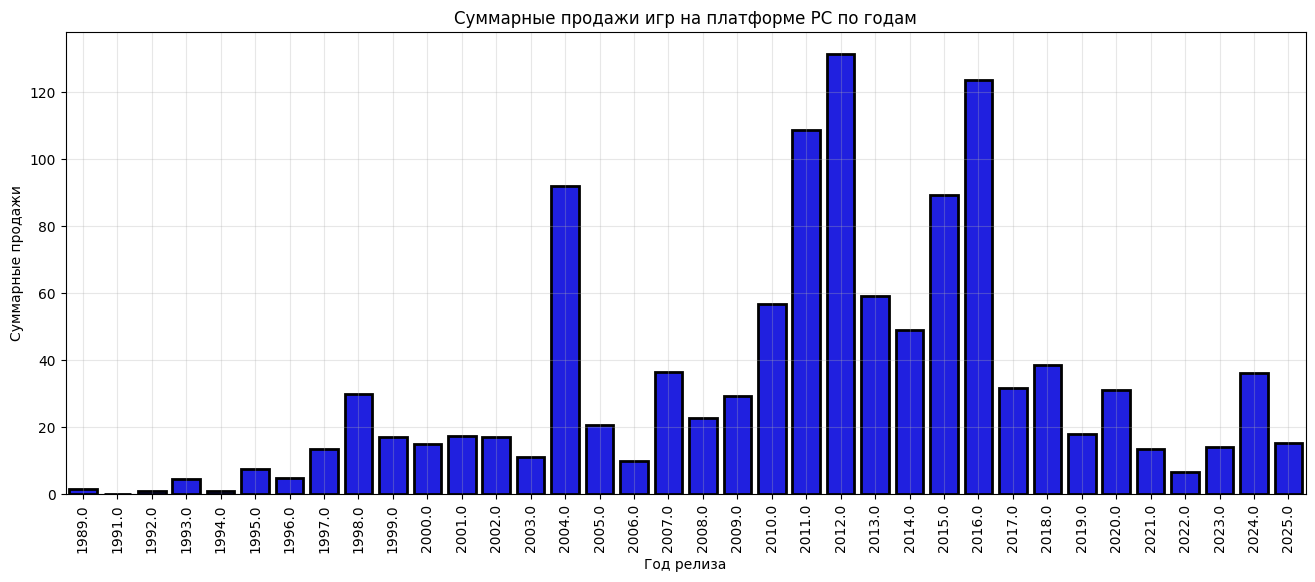

In [620]:
plt.figure(figsize=(16, 6))
sns.barplot(pc_sales, x='year', y='total_sales', color='blue', edgecolor='black', linewidth=2)

plt.grid(True, alpha=0.3)
plt.title('Суммарные продажи игр на платформе PC по годам')
plt.xlabel('Год релиза')
plt.ylabel('Суммарные продажи')
plt.xticks(rotation=90)

plt.show()

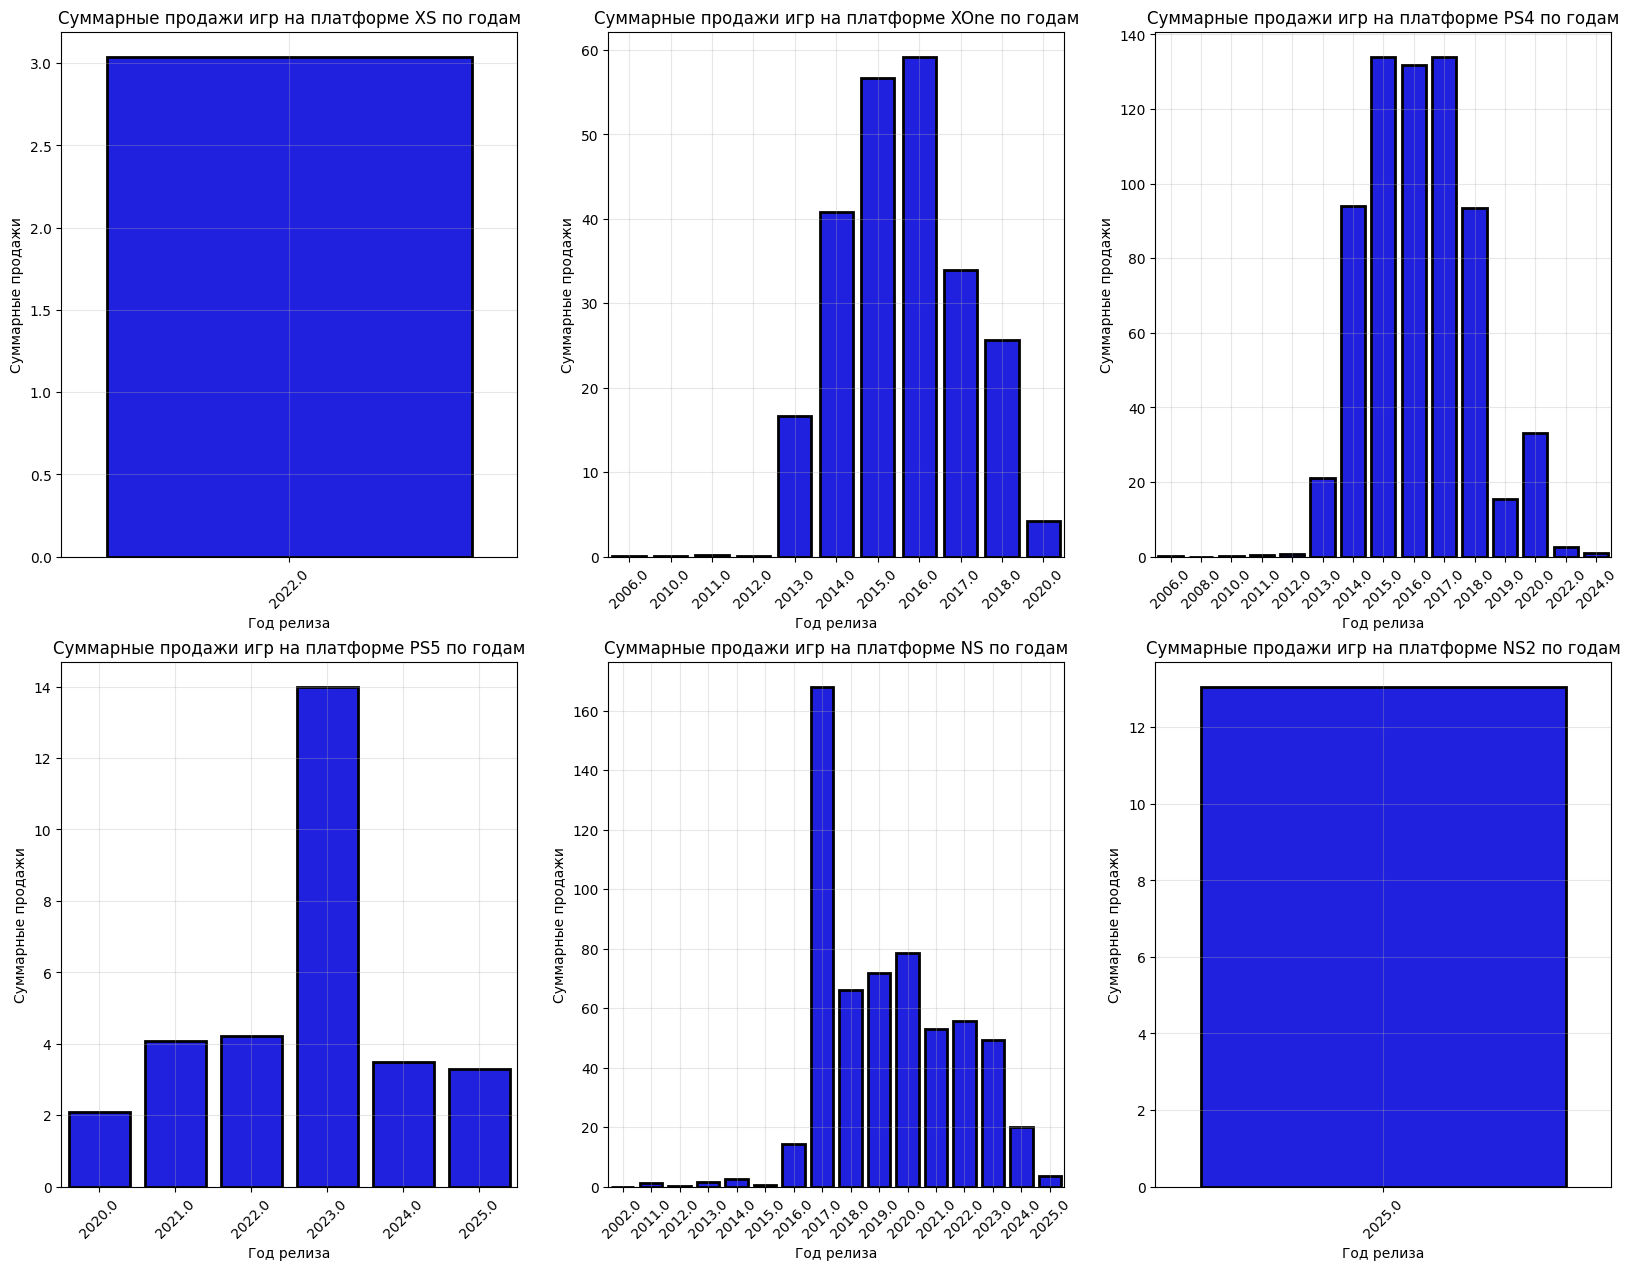

In [621]:
plats_list = ['XS', 'XOne', 'PS4', 'PS5', 'NS', 'NS2']

fig, axes = plt.subplots(2, 3, figsize=(20, 15))
axes = axes.flatten()

for i, platform in enumerate(plats_list):
    sales = plat_df[plat_df['sales_platform'] == platform].groupby('year')['total_sales'].sum().reset_index()
    
    sns.barplot(sales, x='year', y='total_sales', color='blue', edgecolor='black', linewidth=2, ax=axes[i])
    
    axes[i].grid(True, alpha=0.3)
    
    axes[i].set_title(f'Суммарные продажи игр на платформе {platform} по годам')
    axes[i].set_xlabel('Год релиза')
    axes[i].set_ylabel('Суммарные продажи')
    axes[i].tick_params(axis='x', rotation=45)
plt.show()

### Посмотрим по регионам

In [622]:
na_platform_data = plat_df.pivot_table(index='sales_platform', values='na_sales', aggfunc='sum').sort_values(by='na_sales', ascending=False)
eu_platform_data = plat_df.pivot_table(index='sales_platform', values='pal_sales', aggfunc='sum').sort_values(by='pal_sales', ascending=False)
jp_platform_data = plat_df.pivot_table(index='sales_platform', values='jp_sales', aggfunc='sum').sort_values(by='jp_sales', ascending=False)

In [623]:
def process_platform(data):
    top_7 = data.head(7)
    other = pd.DataFrame(data.iloc[7:].sum()).T
    other.index = ['Другие']
    return pd.concat([top_7, other])

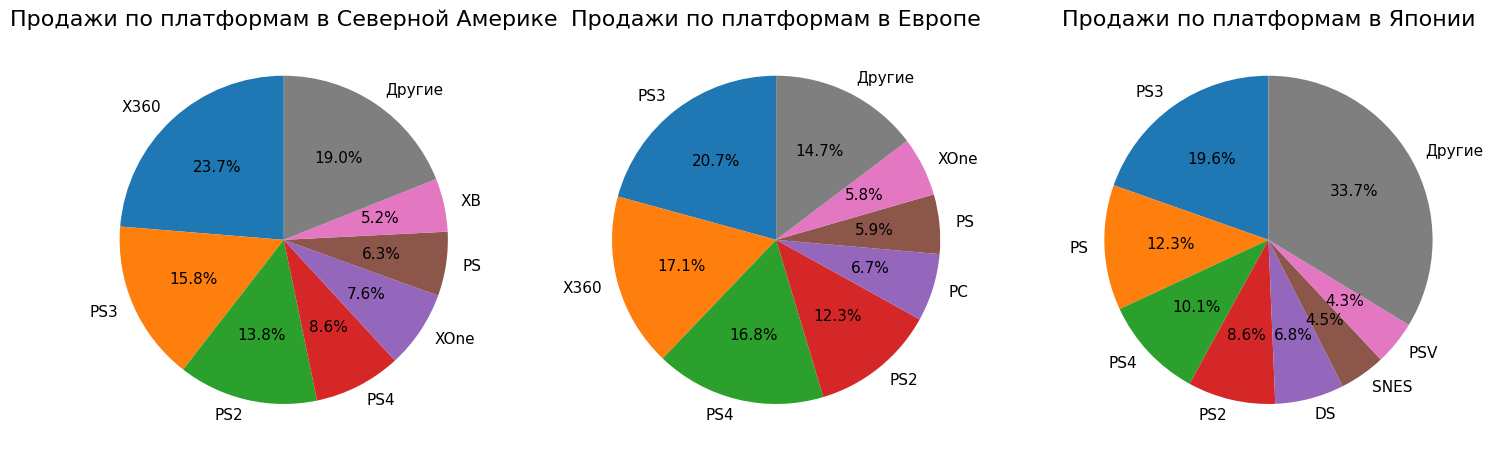

In [624]:
na_platform_data = process_platform(na_platform_data)
eu_platform_data = process_platform(eu_platform_data)
jp_platform_data = process_platform(jp_platform_data)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].pie(na_platform_data['na_sales'], labels=na_platform_data.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Продажи по платформам в Северной Америке', fontsize=16)

axes[1].pie(eu_platform_data['pal_sales'], labels=eu_platform_data.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Продажи по платформам в Европе', fontsize=16)

axes[2].pie(jp_platform_data['jp_sales'], labels=jp_platform_data.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[2].set_title('Продажи по платформам в Японии', fontsize=16)

plt.show()

## Делаем фокусы с возрастными рейтингами

In [625]:
df_all.head()

,first_release_date,game_modes,genres,name,platforms,rating,summary,themes,total_rating,game_type,storyline,age_ratings,hypes,total_sales,na_sales,jp_sales,pal_sales,other_sales,sales_platform,year,month,is_all
191,1989-11-01,Single player,"Puzzle, Arcade",Tetris,All,86.282726,Tetris is a tile-matching puzzle video game. T...,NaN,86.282726,8,NaN,[48954],NaN,520.0,NaN,NaN,NaN,NaN,NaN,1989.0,11.0,True
308,2003-10-29,"Single player, Multiplayer",Shooter,Call of Duty,All,81.336918,"""Call of Duty"" (2003) is the inaugural game in...","Action, Historical, Warfare",84.001792,0,NaN,"[226606, 211389, 167717, 28046, 28047]",NaN,500.0,NaN,NaN,NaN,NaN,NaN,2003.0,10.0,True
798,1997-10-21,"Single player, Multiplayer","Shooter, Racing, Adventure",Grand Theft Auto,All,75.156282,Grand Theft Auto is the first game in the Gran...,"Action, Sandbox, Open world",77.578141,0,"As an aspiring young thug, your mission in thi...","[44933, 47933, 47811, 47812, 47813, 47814, 1067]",NaN,460.0,NaN,NaN,NaN,NaN,NaN,1997.0,10.0,True
500,2016-12-19,"Single player, Multiplayer, Co-operative, Spli...","Simulator, Adventure, Arcade",Minecraft,All,81.434411,Minecraft focuses on allowing the player to ex...,"Action, Fantasy, Survival, Sandbox, Kids, Open...",81.434411,11,Bedrock Edition (also known as the Bedrock Ver...,"[221145, 47378, 47381, 47377, 47379, 33580, 47...",NaN,350.0,NaN,NaN,NaN,NaN,NaN,2016.0,12.0,True
851,2007-11-13,Single player,"Platform, Adventure",Assassin's Creed,All,73.269412,Assassin's Creed is a non-linear action-advent...,"Action, Fantasy, Science fiction, Historical, ...",77.009706,0,"Desmond Miles, a bartender, is kidnapped by th...","[226697, 1225, 81620, 91906, 34079]",NaN,230.0,NaN,NaN,NaN,NaN,NaN,2007.0,11.0,True


In [626]:
col_for_merge = df_all['age_ratings'].reset_index()

col_for_merge['age_ratings'] = col_for_merge['age_ratings'].str.replace('[', '').str.replace(']', '').str.split(', ')
col_for_merge = col_for_merge.explode('age_ratings')
col_for_merge['age_ratings'] = col_for_merge['age_ratings'].fillna(0).astype(int)
col_for_merge.head()

,index,age_ratings
0,191,48954
1,308,226606
1,308,211389
1,308,167717
1,308,28046


In [627]:
age_ratings = pd.read_csv('data/age_ratings_merged.csv')
age_ratings['id'] = age_ratings['id'].astype(int)
age_ratings['rating'] = age_ratings['rating'].astype(str)
age_ratings.head()

,id,name,rating,description
0,3,ESRB,M,"Blood, Violence"
1,10,ESRB,T,"Violence, Blood"
2,23,ESRB,E,no_description
3,24,ESRB,E,no_description
4,25,ESRB,E,no_description


In [628]:
age = pd.read_excel('data/rating_age.xlsx')
age['rating'] = age['rating'].astype(str)
age.head()

,id_x,rating,name,min_age
0,1,RP,ESRB,NaN
1,2,EC,ESRB,3.0
2,3,E,ESRB,6.0
3,4,E10+,ESRB,10.0
4,5,T,ESRB,13.0


In [629]:
age_ratings = age_ratings.merge(age, left_on = ['name', 'rating'], right_on = ['name', 'rating'], how = 'left').drop(columns = ['id_x'])
age_ratings

,id,name,rating,description,min_age
0,3,ESRB,M,"Blood, Violence",17.0
1,10,ESRB,T,"Violence, Blood",13.0
2,23,ESRB,E,no_description,6.0
3,24,ESRB,E,no_description,6.0
4,25,ESRB,E,no_description,6.0
...,...,...,...,...,...
28206,233094,GRAC,12+,"Sexuality, Violence",12.0
28207,233152,ESRB,M,"Blood and Gore, Language, Nudity, Sexual Theme...",17.0
28208,233165,PEGI,16,no_description,16.0
28209,233299,ESRB,M,no_description,17.0


In [630]:
age_ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 28211 entries, 0 to 28210
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           28211 non-null  int64  
 1   name         28211 non-null  str    
 2   rating       28211 non-null  str    
 3   description  28211 non-null  str    
 4   min_age      28204 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 1.1 MB


In [631]:
col_for_merge = col_for_merge.merge(age_ratings, left_on='age_ratings', right_on='id', how='left').set_index('index')
# col_for_merge.head()

col_for_merge.drop(columns=['age_ratings', 'id'], inplace=True)
col_for_merge.rename(columns={'name': 'organisation', 'rating': 'age_rating'}, inplace=True)

col_for_merge.head()

,organisation,age_rating,description,min_age
index,,,,
191,CLASS_IND,L,no_description,0.0
308,ACB,MA 15+,no_description,15.0
308,USK,18,no_description,18.0
308,CLASS_IND,18,"Violência (Violence), Violência Extrema (Extre...",18.0
308,ESRB,T,"Blood, Violence",13.0


In [632]:
df_all = df_all.join(col_for_merge)
df_all.head()

,first_release_date,game_modes,genres,name,platforms,rating,summary,themes,total_rating,game_type,storyline,age_ratings,hypes,total_sales,na_sales,jp_sales,pal_sales,other_sales,sales_platform,year,month,is_all,organisation,age_rating,description,min_age
191,1989-11-01,Single player,"Puzzle, Arcade",Tetris,All,86.282726,Tetris is a tile-matching puzzle video game. T...,NaN,86.282726,8,NaN,[48954],NaN,520.0,NaN,NaN,NaN,NaN,NaN,1989.0,11.0,True,CLASS_IND,L,no_description,0.0
308,2003-10-29,"Single player, Multiplayer",Shooter,Call of Duty,All,81.336918,"""Call of Duty"" (2003) is the inaugural game in...","Action, Historical, Warfare",84.001792,0,NaN,"[226606, 211389, 167717, 28046, 28047]",NaN,500.0,NaN,NaN,NaN,NaN,NaN,2003.0,10.0,True,ACB,MA 15+,no_description,15.0
308,2003-10-29,"Single player, Multiplayer",Shooter,Call of Duty,All,81.336918,"""Call of Duty"" (2003) is the inaugural game in...","Action, Historical, Warfare",84.001792,0,NaN,"[226606, 211389, 167717, 28046, 28047]",NaN,500.0,NaN,NaN,NaN,NaN,NaN,2003.0,10.0,True,USK,18,no_description,18.0
308,2003-10-29,"Single player, Multiplayer",Shooter,Call of Duty,All,81.336918,"""Call of Duty"" (2003) is the inaugural game in...","Action, Historical, Warfare",84.001792,0,NaN,"[226606, 211389, 167717, 28046, 28047]",NaN,500.0,NaN,NaN,NaN,NaN,NaN,2003.0,10.0,True,CLASS_IND,18,"Violência (Violence), Violência Extrema (Extre...",18.0
308,2003-10-29,"Single player, Multiplayer",Shooter,Call of Duty,All,81.336918,"""Call of Duty"" (2003) is the inaugural game in...","Action, Historical, Warfare",84.001792,0,NaN,"[226606, 211389, 167717, 28046, 28047]",NaN,500.0,NaN,NaN,NaN,NaN,NaN,2003.0,10.0,True,ESRB,T,"Blood, Violence",13.0


## Наконец смотрим на возрастные рейтинги

In [633]:
# Определим группу возраста по min_age
def age_group(min_age):
    if pd.isna(min_age):
        return 'unknown'
    elif min_age == 0:
        return 'all'
    elif min_age <= 12:
        return 'kids'
    elif min_age <= 17:
        return 'teen'
    else:
        return 'adult'

df_all['age_group'] = df_all['min_age'].apply(age_group)

In [634]:
df_all.drop_duplicates(subset=['name', 'age_group'], inplace = True)
df_all.head()

,first_release_date,game_modes,genres,name,platforms,rating,summary,themes,total_rating,game_type,storyline,age_ratings,hypes,total_sales,na_sales,jp_sales,pal_sales,other_sales,sales_platform,year,month,is_all,organisation,age_rating,description,min_age,age_group
191,1989-11-01,Single player,"Puzzle, Arcade",Tetris,All,86.282726,Tetris is a tile-matching puzzle video game. T...,NaN,86.282726,8,NaN,[48954],NaN,520.0,NaN,NaN,NaN,NaN,NaN,1989.0,11.0,True,CLASS_IND,L,no_description,0.0,all
308,2003-10-29,"Single player, Multiplayer",Shooter,Call of Duty,All,81.336918,"""Call of Duty"" (2003) is the inaugural game in...","Action, Historical, Warfare",84.001792,0,NaN,"[226606, 211389, 167717, 28046, 28047]",NaN,500.0,NaN,NaN,NaN,NaN,NaN,2003.0,10.0,True,ACB,MA 15+,no_description,15.0,teen
308,2003-10-29,"Single player, Multiplayer",Shooter,Call of Duty,All,81.336918,"""Call of Duty"" (2003) is the inaugural game in...","Action, Historical, Warfare",84.001792,0,NaN,"[226606, 211389, 167717, 28046, 28047]",NaN,500.0,NaN,NaN,NaN,NaN,NaN,2003.0,10.0,True,USK,18,no_description,18.0,adult
798,1997-10-21,"Single player, Multiplayer","Shooter, Racing, Adventure",Grand Theft Auto,All,75.156282,Grand Theft Auto is the first game in the Gran...,"Action, Sandbox, Open world",77.578141,0,"As an aspiring young thug, your mission in thi...","[44933, 47933, 47811, 47812, 47813, 47814, 1067]",NaN,460.0,NaN,NaN,NaN,NaN,NaN,1997.0,10.0,True,PEGI,16,"Violence, Bad Language",16.0,teen
798,1997-10-21,"Single player, Multiplayer","Shooter, Racing, Adventure",Grand Theft Auto,All,75.156282,Grand Theft Auto is the first game in the Gran...,"Action, Sandbox, Open world",77.578141,0,"As an aspiring young thug, your mission in thi...","[44933, 47933, 47811, 47812, 47813, 47814, 1067]",NaN,460.0,NaN,NaN,NaN,NaN,NaN,1997.0,10.0,True,GRAC,19+,"Violence, Crime, Anti-Social",19.0,adult


In [635]:
df_all['is_all'] = df_all['platforms'] == 'All'

has_all = df_all.groupby(['name', 'year'])['is_all'].transform('any')

# где All есть оставляем только строки All
df_with_all = df_all[has_all & df_all['is_all']][['name', 'year', 'age_group', 'total_sales', 'first_release_date', 'genres', 'themes', 'game_modes']]

game_has_all = df_all.groupby('name')['is_all'].transform('any')
# где All нет сумма по всем платформам
df_without_all = df_all[~game_has_all]

df_without_all = df_without_all.groupby(['name', 'year', 'age_group']).agg({'total_sales': 'sum','first_release_date': 'min', 'genres': 'first', 'themes' : longest_string, 'game_modes': longest_string}).reset_index()


display(df_with_all.head())
display(df_without_all.head())

,name,year,age_group,total_sales,first_release_date,genres,themes,game_modes
191,Tetris,1989.0,all,520.0,1989-11-01,"Puzzle, Arcade",NaN,Single player
308,Call of Duty,2003.0,teen,500.0,2003-10-29,Shooter,"Action, Historical, Warfare","Single player, Multiplayer"
308,Call of Duty,2003.0,adult,500.0,2003-10-29,Shooter,"Action, Historical, Warfare","Single player, Multiplayer"
798,Grand Theft Auto,1997.0,teen,460.0,1997-10-21,"Shooter, Racing, Adventure","Action, Sandbox, Open world","Single player, Multiplayer"
798,Grand Theft Auto,1997.0,adult,460.0,1997-10-21,"Shooter, Racing, Adventure","Action, Sandbox, Open world","Single player, Multiplayer"


,name,year,age_group,total_sales,first_release_date,genres,themes,game_modes
0,.Hack//G.U. Vol. 1: Rebirth,2006.0,teen,0.16,2006-05-18,Role-playing (RPG),"Action, Fantasy, Science fiction",Single player
1,140,2013.0,kids,0.14,2013-10-16,"Music, Platform, Puzzle, Strategy, Indie",Action,Single player
2,2010 FIFA World Cup South Africa,2010.0,all,1.23,2010-04-27,"Simulator, Sport","Action, Non-fiction","Single player, Split screen"
3,2010 FIFA World Cup South Africa,2010.0,kids,1.23,2010-04-27,"Simulator, Sport","Action, Non-fiction","Single player, Split screen"
4,2014 FIFA World Cup Brazil,2014.0,all,0.66,2014-04-15,Sport,Non-fiction,"Single player, Multiplayer, Split screen"


In [636]:
sales_age_all = pd.concat([df_with_all, df_without_all], ignore_index=True)
sales_age_all['year'] = sales_age_all['year'].astype('int')
sales_age_all.head()

,name,year,age_group,total_sales,first_release_date,genres,themes,game_modes
0,Tetris,1989,all,520.0,1989-11-01,"Puzzle, Arcade",NaN,Single player
1,Call of Duty,2003,teen,500.0,2003-10-29,Shooter,"Action, Historical, Warfare","Single player, Multiplayer"
2,Call of Duty,2003,adult,500.0,2003-10-29,Shooter,"Action, Historical, Warfare","Single player, Multiplayer"
3,Grand Theft Auto,1997,teen,460.0,1997-10-21,"Shooter, Racing, Adventure","Action, Sandbox, Open world","Single player, Multiplayer"
4,Grand Theft Auto,1997,adult,460.0,1997-10-21,"Shooter, Racing, Adventure","Action, Sandbox, Open world","Single player, Multiplayer"


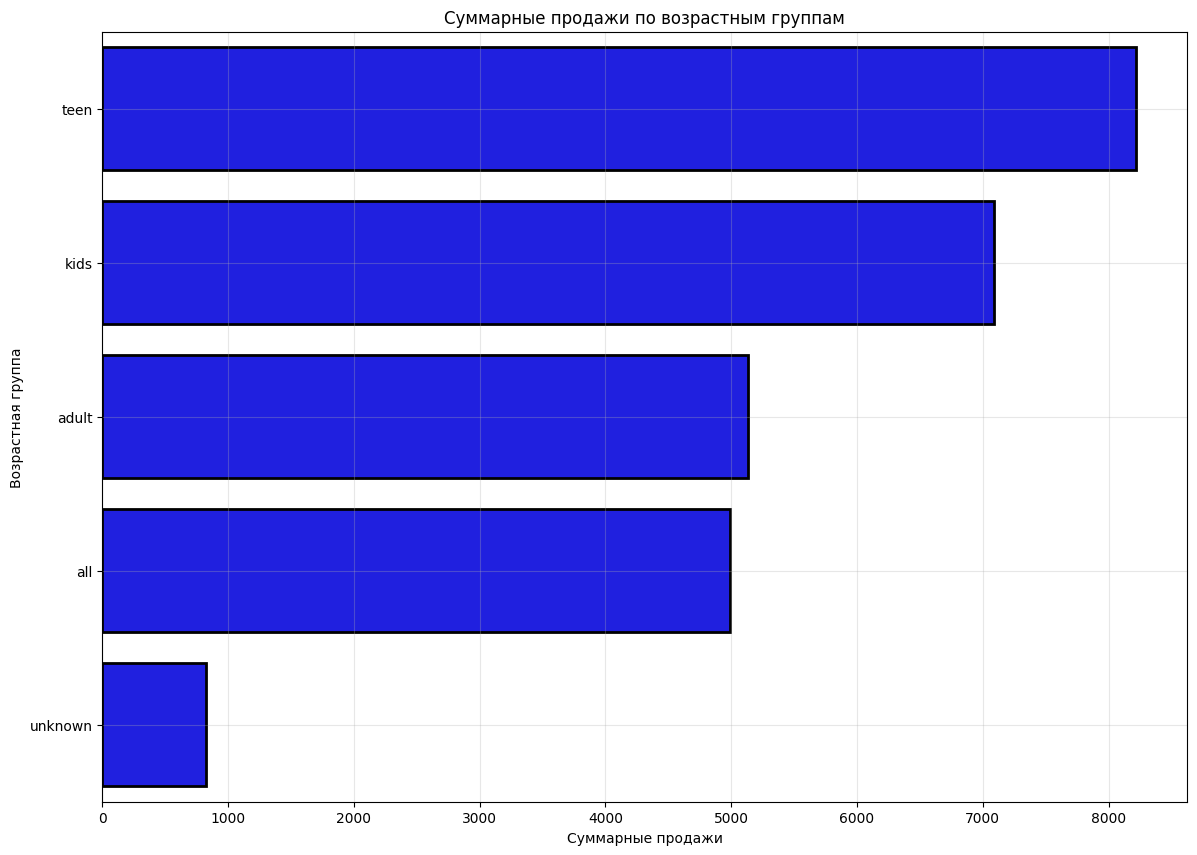

In [637]:
sales_by_age = sales_age_all.groupby('age_group')['total_sales'].sum().reset_index().sort_values(by='total_sales', ascending=False)

plt.figure(figsize=(14, 10))

sns.barplot(sales_by_age, x='total_sales', y='age_group', color='blue', edgecolor='black', linewidth=2)

plt.grid(True, alpha=0.3)
plt.title('Суммарные продажи по возрастным группам')
plt.xlabel('Суммарные продажи')
plt.ylabel('Возрастная группа')

plt.show()

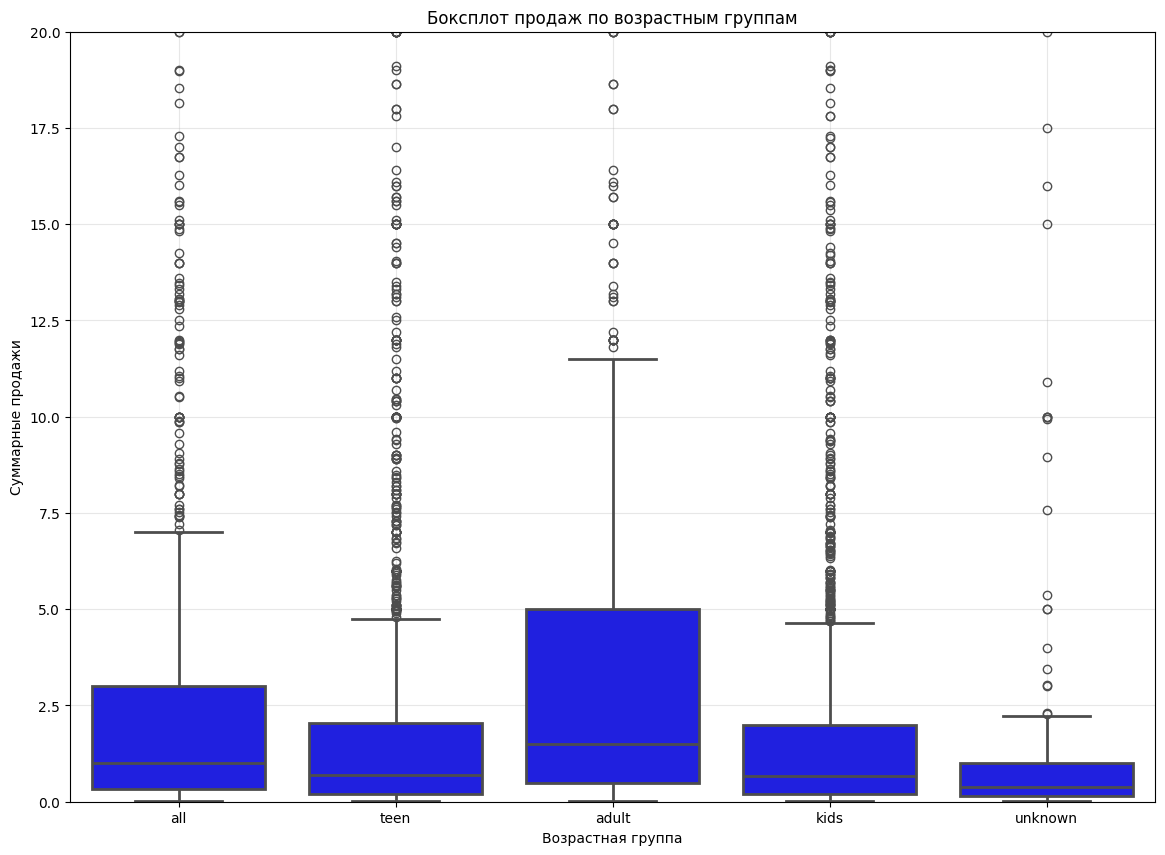

In [638]:
plt.figure(figsize=(14, 10))

sns.boxplot(sales_age_all, x='age_group', y='total_sales', color='blue', linewidth=2)

plt.grid(True, alpha=0.3)
plt.title('Боксплот продаж по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylim(0, 20)
plt.ylabel('Суммарные продажи')

plt.show()